In [ ]:
# ==============================================================
# FRB Isotropy Test
# LEVEL 1: with mask, no SF, no JK
#
#   "Masked sky vs. masked isotropic realization"
# ==============================================================

import numpy as np
import pandas as pd
import treecorr
import os
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ks_2samp
import seaborn as sns
from astropy.coordinates import SkyCoord
import astropy.units as u

In [ ]:
# ==============================================================
# 1. GENERAL CONFIGURATIONS
# ==============================================================

BASE_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/"
ALL_FRB_PATH = os.path.join(BASE_PATH, "SkyPosition.csv")

N_RAND_FACTOR = 20
N_MOCKS = 200

# --- Mask configuration (Level 1)
GAL_CUT = 20.0  # degrees

USE_LOG = False
MAX_SEP = 180.0
MIN_SEP = 0.1

if USE_LOG:
    BIN_TYPE = 'Log'
    N_BINS = 20
else:
    BIN_TYPE = 'Linear'
    BIN_SIZE = 1.8
    N_BINS = int((MAX_SEP - MIN_SEP) / BIN_SIZE)

COARSE_BINS = np.arange(0, 181, 20)
COARSE_CENTERS = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])

In [3]:
# ==============================================================
# 2. MASK FUNCTION (LEVEL 1)
# ==============================================================

def apply_mask(df):
    """
    Apply Galactic mask: |b| > GAL_CUT
    """

    coords = SkyCoord(
        ra=df['RA'].values * u.degree,
        dec=df['DEC'].values * u.degree,
        frame='icrs'
    )

    b = coords.galactic.b.degree

    return df[np.abs(b) > GAL_CUT].reset_index(drop=True)


# ==============================================================
# 2. LOAD CATALOG
# ==============================================================

def load_catalog(path):
    """Load RA/DEC columns and drop NaNs."""
    return pd.read_csv(path)[["RA", "DEC"]].dropna()


# ==============================================================
# 3. ISOTROPIC CATALOG
# ==============================================================

def generate_isotropic_catalog(n, seed=None):
    """
    Generate isotropic sky (uniform on sphere)
    """
    rng = np.random.default_rng(seed)
    ra = 360.0 * rng.random(n)
    dec = np.degrees(np.arcsin(2.0 * rng.random(n) - 1.0))
    return pd.DataFrame({"RA": ra, "DEC": dec})

In [4]:
# ==============================================================
# 4. 2pACF (LANDY–SZALAY)
# ==============================================================

def compute_2pacf(df_data, df_rand, log_spacing=False):

    cat_data = treecorr.Catalog(
        ra=df_data["RA"], dec=df_data["DEC"],
        ra_units="deg", dec_units="deg"
    )

    cat_rand = treecorr.Catalog(
        ra=df_rand["RA"], dec=df_rand["DEC"],
        ra_units="deg", dec_units="deg"
    )

    bin_type = 'Log' if log_spacing else 'Linear'

    corr = treecorr.NNCorrelation(
        min_sep=MIN_SEP,
        max_sep=MAX_SEP,
        nbins=N_BINS,
        sep_units="deg",
        metric='Arc',
        bin_type=bin_type
    )

    rr = treecorr.NNCorrelation(**corr.config)
    dr = treecorr.NNCorrelation(**corr.config)

    corr.process(cat_data)
    rr.process(cat_rand)
    dr.process(cat_data, cat_rand)

    corr.calculateXi(rr=rr, dr=dr)

    theta = np.exp(corr.meanlogr)

    return theta, corr.xi

# ==============================================================
# 5. ABSOLUTE SUM TEST
# ==============================================================

def get_absolute_sum(theta, w):

    vals = []

    for i in range(len(COARSE_BINS) - 1):

        mask = (theta >= COARSE_BINS[i]) & (theta < COARSE_BINS[i+1])

        if np.any(mask):
            vals.append(np.abs(np.mean(w[mask])))
        else:
            vals.append(0.0)

    return np.array(vals)

In [5]:
# ==============================================================
# 6. OBSERVATIONAL DATA (LEVEL 1)
# ==============================================================

print(f"\n--- Processing data ({BIN_TYPE}) ---")

# Apply mask to data
df_data = apply_mask(load_catalog(ALL_FRB_PATH))

# Apply SAME mask to randoms
df_rand = apply_mask(
    generate_isotropic_catalog(
        len(df_data) * N_RAND_FACTOR,
        seed=2000
    )
)

theta, w = compute_2pacf(df_data, df_rand, log_spacing=USE_LOG)

mean_w_obs = w
mean_abs_obs = get_absolute_sum(theta, w)


--- Processing data (Linear) ---


In [6]:
# ==============================================================
# 7. H0 MOCKS (LEVEL 1)
# ==============================================================

print("\n--- Generating H0 mocks ---")

n_avg = len(df_data)

all_w_h0 = []
all_abs_h0 = []

for i in tqdm(range(N_MOCKS)):

    # isotropic sky
    d_iso = apply_mask(
        generate_isotropic_catalog(n_avg, seed=i)
    )

    r_iso = apply_mask(
        generate_isotropic_catalog(
            len(d_iso) * N_RAND_FACTOR,
            seed=i + 5000
        )
    )

    theta_h0, w_h0 = compute_2pacf(
        d_iso, r_iso,
        log_spacing=USE_LOG
    )

    all_w_h0.append(w_h0)
    all_abs_h0.append(get_absolute_sum(theta_h0, w_h0))

all_w_h0 = np.array(all_w_h0)
all_abs_h0 = np.array(all_abs_h0)

h0_mean = np.mean(all_w_h0, axis=0)
h0_std = np.std(all_w_h0, axis=0)

h0_abs_mean = np.mean(all_abs_h0, axis=0)
h0_abs_std = np.std(all_abs_h0, axis=0)


--- Generating H0 mocks ---


  0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
# ==============================================================
# 8. STATISTICS
# ==============================================================

print("\n--- Statistical tests ---")

cov = np.cov(all_w_h0, rowvar=False)
inv_cov = np.linalg.pinv(cov)

delta = mean_w_obs - h0_mean

chi2 = delta @ inv_cov @ delta
dof = len(delta)

print(f"Chi2/dof = {chi2/dof:.2f}")

ks_stat, ks_p = ks_2samp(mean_abs_obs, h0_abs_mean)

print(f"KS p-value = {ks_p:.4e}")


--- Statistical tests ---
Chi2/dof = 8447.71
KS p-value = 4.1135e-05


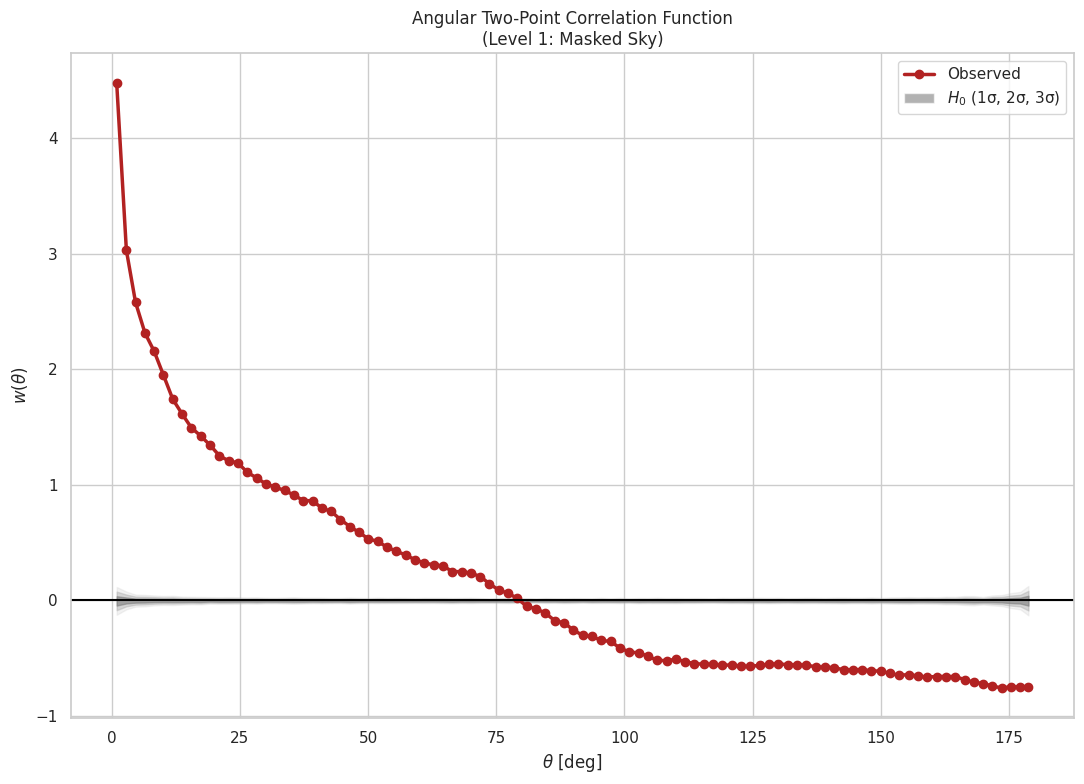

In [8]:
# ==============================================================
# 9. PLOT — 2pACF
# ==============================================================

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 8))

# H0 bands
ax.fill_between(theta, h0_mean - 3*h0_std, h0_mean + 3*h0_std,
                color='silver', alpha=0.2)
ax.fill_between(theta, h0_mean - 2*h0_std, h0_mean + 2*h0_std,
                color='darkgray', alpha=0.4)
ax.fill_between(theta, h0_mean - h0_std, h0_mean + h0_std,
                color='gray', alpha=0.6)

# Observed
ax.plot(theta, mean_w_obs, 'o-', color='firebrick',
        lw=2.5, label='Observed')

ax.axhline(0, color='black')

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$w(\theta)$')

ax.set_title('Angular Two-Point Correlation Function\n(Level 1: Masked Sky)')

h0_patch = Patch(facecolor='gray', alpha=0.6,
                 label=r'$H_0$ (1σ, 2σ, 3σ)')

handles, labels = ax.get_legend_handles_labels()
handles.append(h0_patch)
labels.append(r'$H_0$ (1σ, 2σ, 3σ)')

ax.legend(handles, labels)

plt.tight_layout()
plt.savefig("FRB_2PACF_level1.png", dpi=300)
plt.show()

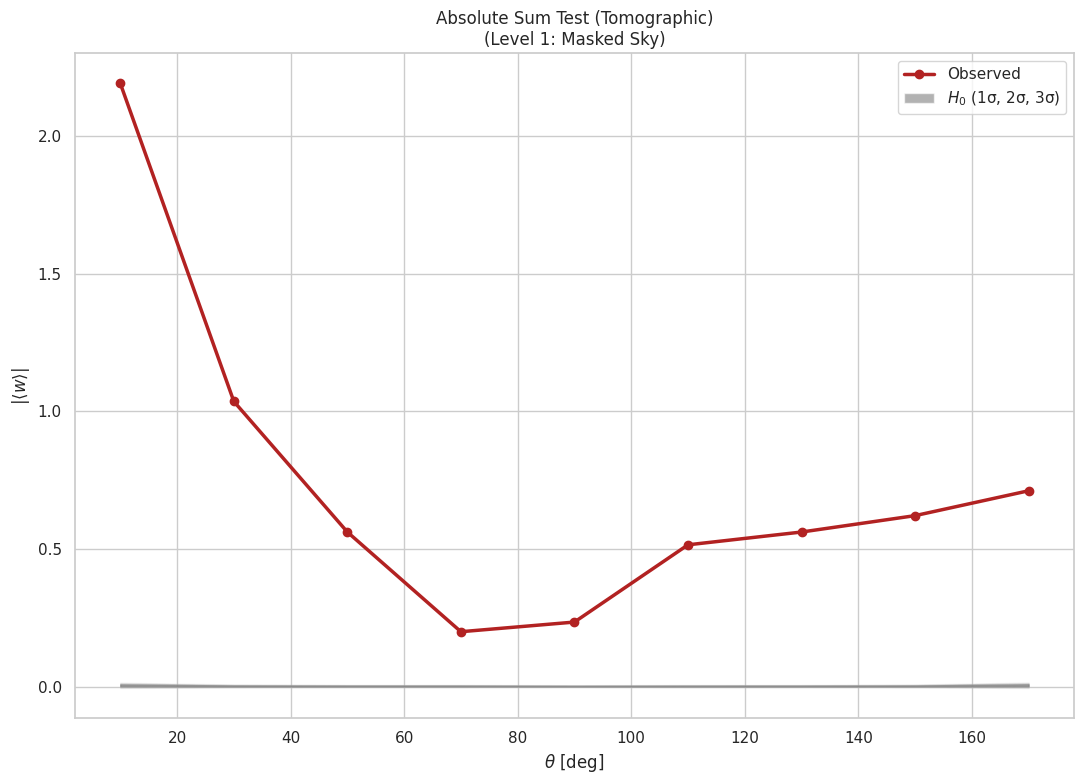

In [9]:
# ==============================================================
# 10. PLOT — ABSOLUTE SUM
# ==============================================================

fig, ax = plt.subplots(figsize=(11, 8))

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - 3*h0_abs_std,
                h0_abs_mean + 3*h0_abs_std,
                color='silver', alpha=0.2)

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - 2*h0_abs_std,
                h0_abs_mean + 2*h0_abs_std,
                color='darkgray', alpha=0.4)

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - h0_abs_std,
                h0_abs_mean + h0_abs_std,
                color='gray', alpha=0.6)

# Observed
ax.plot(COARSE_CENTERS, mean_abs_obs,
        'o-', color='firebrick',
        lw=2.5, label='Observed')

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$|\langle w \rangle|$')

ax.set_title('Absolute Sum Test (Tomographic)\n(Level 1: Masked Sky)')

h0_patch = Patch(facecolor='gray', alpha=0.6,
                 label=r'$H_0$ (1σ, 2σ, 3σ)')

handles, labels = ax.get_legend_handles_labels()
handles.append(h0_patch)
labels.append(r'$H_0$ (1σ, 2σ, 3σ)')

ax.legend(handles, labels)

plt.tight_layout()
plt.savefig("FRB_ABS_level1.png", dpi=300)
plt.show()